# ATE Phase 2 — ATE Model ONLY (chạy song song với Gate notebook)

**Mục đích:** Chạy notebook này trên **Tab Colab #2 (T4)** song song với `ate_phase2_gate_only.ipynb` trên Tab #1.

 Yêu cầu: Notebook Gate phải đã chạy xong cell `gate-py-combine` và file `shared_train_df.parquet` đã xuất hiện trên Drive trước khi chạy cell load dữ liệu ở đây.

**Pipeline:**
1. Load `shared_train_df.parquet` từ Drive (Gate notebook đã tạo)
2. Batch tokenize + BIO labeling
3. Huấn luyện **ATE Model** (roberta-base)
4. Đánh giá trên gold test (span threshold sweep 0.0–0.9)

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
!pip install -q transformers==4.46.0 accelerate==0.34.0 datasets seqeval scikit-learn pyarrow pandas tqdm matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 102.7 MB/s eta 0:00:00


In [7]:
import os

GOLD_TEST_PATH       = "/content/drive/MyDrive/dataset_gold/gold_test.csv"
PHASE2_DIR           = "/content/drive/MyDrive/output_cleaning/absa_self_train_phase2"
ATE_SAVE_PATH        = f"{PHASE2_DIR}/ate_phase2"
REPORT_DIR           = f"{PHASE2_DIR}/reports"
SHARED_TRAIN_PARQUET = f"{PHASE2_DIR}/shared_train_df.parquet"

os.makedirs(ATE_SAVE_PATH, exist_ok=True)
os.makedirs(REPORT_DIR,    exist_ok=True)

MODEL_NAME   = "roberta-base"
MAX_LENGTH   = 192
ATE_EPOCHS   = 3
ATE_BS       = 64
LEARNING_RATE   = 2e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
GRAD_ACCUM      = 2
DATALOADER_WORKERS = 2
SAVE_TOTAL_LIMIT   = 1
ATE_TOKENIZE_CHUNK = 10_000
RANDOM_SEED        = 1234
EVAL_THRESHOLDS    = [round(t * 0.1, 1) for t in range(10)]

print(f"ATE_BS : {ATE_BS}  (effective {ATE_BS * GRAD_ACCUM})")
print(f"Waiting for: {SHARED_TRAIN_PARQUET}")


ATE_BS : 64  (effective 128)
Waiting for: /content/drive/MyDrive/output_cleaning/absa_self_train_phase2/shared_train_df.parquet


In [8]:
import time

# ── Chờ Gate notebook tạo xong shared_train_df.parquet ───────────────────
# Nếu Gate notebook chạy trước, file này đã có sẵn → skip loop ngay.
MAX_WAIT_SEC = 7200   # chờ tối đa 2 giờ
CHECK_EVERY  = 30     # kiểm tra mỗi 30 giây
waited = 0
while not os.path.exists(SHARED_TRAIN_PARQUET):
    print(f"  [{waited//60:02d}:{waited%60:02d}] Chờ shared_train_df.parquet từ Gate notebook...")
    time.sleep(CHECK_EVERY)
    waited += CHECK_EVERY
    if waited >= MAX_WAIT_SEC:
        raise TimeoutError("Không tìm thấy shared_train_df.parquet sau 2 giờ. Kiểm tra Gate notebook.")


In [9]:
import ast, pandas as pd, numpy as np

def parse_aspects_col(series):
    def _parse(val):
        if isinstance(val, list):
            return [a for a in val if a and str(a).strip()]
        if pd.isna(val) or str(val).strip() in ("", "[]", "nan"):
            return []
        try:
            return [a for a in ast.literal_eval(str(val)) if a and str(a).strip()]
        except Exception:
            return []
    return series.apply(_parse)

# Load shared train data (tạo bởi Gate notebook)
train_df = pd.read_parquet(SHARED_TRAIN_PARQUET)
train_df["aspects"] = parse_aspects_col(train_df["aspects"])

# Load gold test
gold_test = pd.read_csv(GOLD_TEST_PATH)
gold_test["aspects"] = parse_aspects_col(gold_test["aspects"])

print(f"Train : {len(train_df):,} samples")
print(f"Test  : {len(gold_test):,} samples")

Train : 1,998,886 samples
Test  : 800 samples


In [10]:
import re, torch

TOKEN_RE = re.compile(r"\b\w+(?:'\w+)?\b")

def clean_text(text):
    if pd.isna(text): return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def tokenize_words(text):
    return [m.group(0) for m in TOKEN_RE.finditer(text)]

def get_word_offsets(text):
    return [(m.start(), m.end(), m.group(0)) for m in TOKEN_RE.finditer(text)]

def text_to_bio_labels(sentence, aspects):
    sentence   = clean_text(sentence)
    offsets    = get_word_offsets(sentence)
    words      = [w for _, _, w in offsets]
    labels     = ["O"] * len(words)
    if not words or not aspects: return words, labels
    sent_lower = sentence.lower()
    for aspect in aspects:
        if not aspect or not str(aspect).strip(): continue
        asp_clean  = clean_text(str(aspect)).lower()
        if not asp_clean: continue
        start_char = sent_lower.find(asp_clean)
        if start_char == -1:
            asp_words = tokenize_words(asp_clean)
            if not asp_words: continue
            pos = sent_lower.find(asp_words[0])
            if pos == -1: continue
            start_char = pos
        end_char = start_char + len(asp_clean)
        indices  = [i for i, (ws, we, _) in enumerate(offsets) if ws >= start_char and we <= end_char]
        if not indices: continue
        labels[indices[0]] = "B-ASP"
        for idx in indices[1:]: labels[idx] = "I-ASP"
    return words, labels

In [11]:
from torch.utils.data import Dataset
from transformers import AutoTokenizer, DataCollatorForTokenClassification
from tqdm.auto import tqdm as tqdm_auto

LABEL_LIST = ["O", "B-ASP", "I-ASP"]
LABEL2ID   = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}

# add_prefix_space=True bắt buộc khi dùng RoBERTa với is_split_into_words=True
ate_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, add_prefix_space=True)

class ATEDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_length=192, chunk_size=10_000):
        sentences = df["sentence_text"].tolist()
        aspects   = df["aspects"].tolist()
        n         = len(sentences)
        print(f"  Generating BIO labels for {n:,} samples...")
        pairs       = [text_to_bio_labels(clean_text(s), a)
                       for s, a in tqdm_auto(zip(sentences, aspects), total=n, desc="BIO")]
        words_list  = [p[0] for p in pairs]
        labels_list = [p[1] for p in pairs]
        print(f"  Batch tokenizing {n:,} samples...")
        self._input_ids = []; self._attention_mask = []; self._labels = []
        for start in tqdm_auto(range(0, n, chunk_size), desc="tokenize"):
            end         = min(start + chunk_size, n)
            chunk_words = [w if w else [""] for w in words_list[start:end]]
            enc = tokenizer(chunk_words, is_split_into_words=True,
                            truncation=True, max_length=max_length, padding=False)
            for j in range(end - start):
                word_ids = enc.word_ids(batch_index=j)
                lbl_seq  = labels_list[start + j]
                aligned  = []
                prev_wid = None
                for wid in word_ids:
                    if wid is None: aligned.append(-100)
                    elif wid != prev_wid: aligned.append(label2id[lbl_seq[wid]] if wid < len(lbl_seq) else 0)
                    else: aligned.append(-100)
                    prev_wid = wid
                self._input_ids.append(enc["input_ids"][j])
                self._attention_mask.append(enc["attention_mask"][j])
                self._labels.append(aligned)
        print(f"  ATEDataset ready — {len(self._input_ids):,} samples")
    def __len__(self): return len(self._labels)
    def __getitem__(self, idx):
        return {
            "input_ids"     : torch.tensor(self._input_ids[idx],     dtype=torch.long),
            "attention_mask": torch.tensor(self._attention_mask[idx],dtype=torch.long),
            "labels"        : torch.tensor(self._labels[idx],        dtype=torch.long),
        }

print("Building ATE train dataset...")
ate_train_ds = ATEDataset(train_df, ate_tokenizer, LABEL2ID, MAX_LENGTH, ATE_TOKENIZE_CHUNK)
print("Building ATE eval dataset...")
ate_eval_ds  = ATEDataset(gold_test, ate_tokenizer, LABEL2ID, MAX_LENGTH, ATE_TOKENIZE_CHUNK)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  ATEDataset ready — 1,998,886 samples
Building ATE eval dataset...
  Generating BIO labels for 800 samples...


BIO:   0%|          | 0/800 [00:00<?, ?it/s]

  Batch tokenizing 800 samples...


tokenize:   0%|          | 0/1 [00:00<?, ?it/s]

  ATEDataset ready — 800 samples


In [12]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer
from seqeval.metrics import f1_score as seq_f1, precision_score as seq_prec, recall_score as seq_rec

device   = "cuda" if torch.cuda.is_available() else "cpu"
_sm      = torch.cuda.get_device_capability() if device == "cuda" else (0, 0)
# bf16 hardware chỉ có từ SM 8.0 (Ampere+). T4=SM7.5 → dùng fp16 native.
_use_bf16    = device == "cuda" and _sm[0] >= 8
_use_fp16    = device == "cuda" and not _use_bf16
_use_compile = device == "cuda" and hasattr(torch, "compile") and _sm[0] >= 8
_optim       = "adamw_torch_fused" if device == "cuda" else "adamw_torch"
print(f"Device={device} | SM={_sm} | "
      f"precision={'bf16' if _use_bf16 else 'fp16' if _use_fp16 else 'fp32'} | compile={_use_compile}")

ate_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABEL_LIST), id2label=ID2LABEL, label2id=LABEL2ID,
).to(device)

def compute_ate_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    true_labels = [[ID2LABEL[l] for l in s if l != -100] for s in labels]
    true_preds  = [[ID2LABEL[p] for p, l in zip(ps, ls) if l != -100]
                   for ps, ls in zip(preds, labels)]
    all_true = [l for s in true_labels for l in s]
    all_pred = [p for s in true_preds  for p in s]
    acc = sum(t == p for t, p in zip(all_true, all_pred)) / len(all_true) if all_true else 0.0
    return {
        "token_accuracy": round(acc,              4),
        "span_precision": round(seq_prec(true_labels, true_preds), 4),
        "span_recall"   : round(seq_rec(true_labels, true_preds),  4),
        "span_f1"       : round(seq_f1(true_labels, true_preds),   4),
    }

ate_args = TrainingArguments(
    output_dir=f"{PHASE2_DIR}/ate_checkpoints",
    num_train_epochs=ATE_EPOCHS,
    per_device_train_batch_size=ATE_BS,
    per_device_eval_batch_size=ATE_BS * 4,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=SAVE_TOTAL_LIMIT,
    load_best_model_at_end=True,
    metric_for_best_model="span_f1",
    greater_is_better=True,
    logging_steps=500,
    fp16=_use_fp16, bf16=_use_bf16, optim=_optim,
    group_by_length=True,
    dataloader_num_workers=DATALOADER_WORKERS,
    dataloader_pin_memory=(device == "cuda"),
    torch_compile=_use_compile,
    report_to="none",
)

ate_trainer = Trainer(
    model=ate_model, args=ate_args,
    train_dataset=ate_train_ds, eval_dataset=ate_eval_ds,
    compute_metrics=compute_ate_metrics,
    data_collator=DataCollatorForTokenClassification(ate_tokenizer),
)
print("Starting ATE training...")
ate_trainer.train()


Device=cuda | SM=(7, 5) | precision=fp16 | compile=False


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Starting ATE training...


Epoch,Training Loss,Validation Loss,Token Accuracy,Span Precision,Span Recall,Span F1
0,0.062100,0.195381,0.952100,0.618400,0.636200,0.627200
2,0.042500,0.232311,0.954400,0.635600,0.634600,0.635100


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


TrainOutput(global_step=46848, training_loss=0.06506730542808283, metrics={'train_runtime': 8196.6602, 'train_samples_per_second': 731.598, 'train_steps_per_second': 5.715, 'total_flos': 6.765082983047456e+16, 'train_loss': 0.06506730542808283, 'epoch': 2.9999039477475744})

In [13]:
ate_trainer.save_model(ATE_SAVE_PATH)
ate_tokenizer.save_pretrained(ATE_SAVE_PATH)
print(f"ATE model saved → {ATE_SAVE_PATH}")

ATE model saved → /content/drive/MyDrive/output_cleaning/absa_self_train_phase2/ate_phase2


## Đánh Giá ATE — Span Threshold Sweep

In [14]:
import gc
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForTokenClassification

eval_ate_tokenizer = AutoTokenizer.from_pretrained(ATE_SAVE_PATH, use_fast=True)
eval_ate_model     = AutoModelForTokenClassification.from_pretrained(ATE_SAVE_PATH).to(device)
if device == "cuda": eval_ate_model.half()
eval_ate_model.eval()

EVAL_BATCH = 128 if device == "cuda" else 32

def _decode_bio_spans(tokens, labels, confidences):
    spans = []
    i = 0
    while i < len(labels):
        if labels[i] == "B-ASP":
            start = i; i += 1
            while i < len(labels) and labels[i] == "I-ASP": i += 1
            text = re.sub(r"\s+", " ", " ".join(tokens[start:i])).strip(" .,;:!?()[]{}\"'")
            if text: spans.append({"aspect": text, "confidence": float(np.mean(confidences[start:i]))})
        else: i += 1
    best = {}
    for s in spans:
        k = s["aspect"]
        if k not in best or s["confidence"] > best[k]["confidence"]: best[k] = s
    return sorted(best.values(), key=lambda x: (-x["confidence"], x["aspect"]))

def predict_ate_batch_eval(sentences, batch_size=EVAL_BATCH):
    all_tokens = [tokenize_words(clean_text(s)) for s in sentences]
    results    = [None] * len(sentences)
    id2lbl     = eval_ate_model.config.id2label
    for i, toks in enumerate(all_tokens):
        if not toks: results[i] = {"spans": []}
    non_empty = [(i, t) for i, t in enumerate(all_tokens) if t]
    for start in tqdm(range(0, len(non_empty), batch_size), desc="ate inference"):
        sub = non_empty[start:start + batch_size]
        indices, token_lists = zip(*sub)
        enc = eval_ate_tokenizer(list(token_lists), is_split_into_words=True,
                                 truncation=True, max_length=MAX_LENGTH, padding=True, return_tensors="pt")
        word_ids_batch = [enc.word_ids(batch_index=j) for j in range(len(token_lists))]
        with torch.inference_mode():
            logits   = eval_ate_model(**{k: v.to(device) for k, v in enc.items()}).logits
            probs    = torch.softmax(logits.float(), dim=-1).cpu().numpy()
            pred_ids = probs.argmax(axis=-1)
        for j, (orig_idx, tokens) in enumerate(zip(indices, token_lists)):
            word_labels = ["O"] * len(tokens)
            word_confs  = [0.0]  * len(tokens)
            seen = set()
            for tok_idx, wid in enumerate(word_ids_batch[j]):
                if wid is None or wid in seen: continue
                seen.add(wid)
                pid = int(pred_ids[j, tok_idx])
                word_labels[wid] = id2lbl[pid]
                word_confs[wid]  = float(probs[j, tok_idx, pid])
            results[orig_idx] = {"tokens": list(tokens), "spans": _decode_bio_spans(tokens, word_labels, word_confs)}
    gc.collect()
    return results

test_sentences    = [clean_text(t) for t in gold_test["sentence_text"]]
test_aspects_true = gold_test["aspects"].tolist()
ate_raw_results   = predict_ate_batch_eval(test_sentences)

def evaluate_ate_at_threshold(raw_results, true_aspects_list, thr):
    tp = fp = fn = exact_match = 0
    for res, true_asp in zip(raw_results, true_aspects_list):
        pred_set = {s["aspect"].lower().strip() for s in res["spans"] if s["confidence"] >= thr}
        true_set = {a.lower().strip() for a in true_asp if a and str(a).strip()}
        tp += len(pred_set & true_set); fp += len(pred_set - true_set); fn += len(true_set - pred_set)
        if pred_set == true_set: exact_match += 1
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return exact_match / len(raw_results) if raw_results else 0.0, prec, rec, f1

ate_threshold_results = []
print(f"{'─'*80}")
print(f"{'Span Thresh':>12}  {'Accuracy':>10}  {'Precision':>10}  {'Recall':>10}  {'F1':>10}")
print(f"{'─'*80}")
for t in EVAL_THRESHOLDS:
    acc, prec, rec, f1 = evaluate_ate_at_threshold(ate_raw_results, test_aspects_true, t)
    ate_threshold_results.append({"span_threshold": t, "accuracy": round(acc,4), "precision": round(prec,4), "recall": round(rec,4), "f1": round(f1,4)})
    print(f"  {t:>10.1f}  {acc:>10.4f}  {prec:>10.4f}  {rec:>10.4f}  {f1:>10.4f}")

ate_result_df = pd.DataFrame(ate_threshold_results)
best = ate_result_df.loc[ate_result_df["f1"].idxmax()]
print(f"\nBest span threshold: {best['span_threshold']}  F1={best['f1']:.4f}")

ate inference:   0%|          | 0/7 [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────
 Span Thresh    Accuracy   Precision      Recall          F1
────────────────────────────────────────────────────────────────────────────────
         0.0      0.6112      0.6578      0.6037      0.6296
         0.1      0.6112      0.6578      0.6037      0.6296
         0.2      0.6112      0.6578      0.6037      0.6296
         0.3      0.6112      0.6578      0.6037      0.6296
         0.4      0.6112      0.6578      0.6037      0.6296
         0.5      0.6112      0.6600      0.6037      0.6306
         0.6      0.6225      0.6851      0.5869      0.6322
         0.7      0.6212      0.7115      0.5640      0.6293
         0.8      0.6150      0.7326      0.5305      0.6154
         0.9      0.6162      0.7672      0.4924      0.5998

Best span threshold: 0.6  F1=0.6322


Saved: /content/drive/MyDrive/output_cleaning/absa_self_train_phase2/reports/ate_threshold_table.png


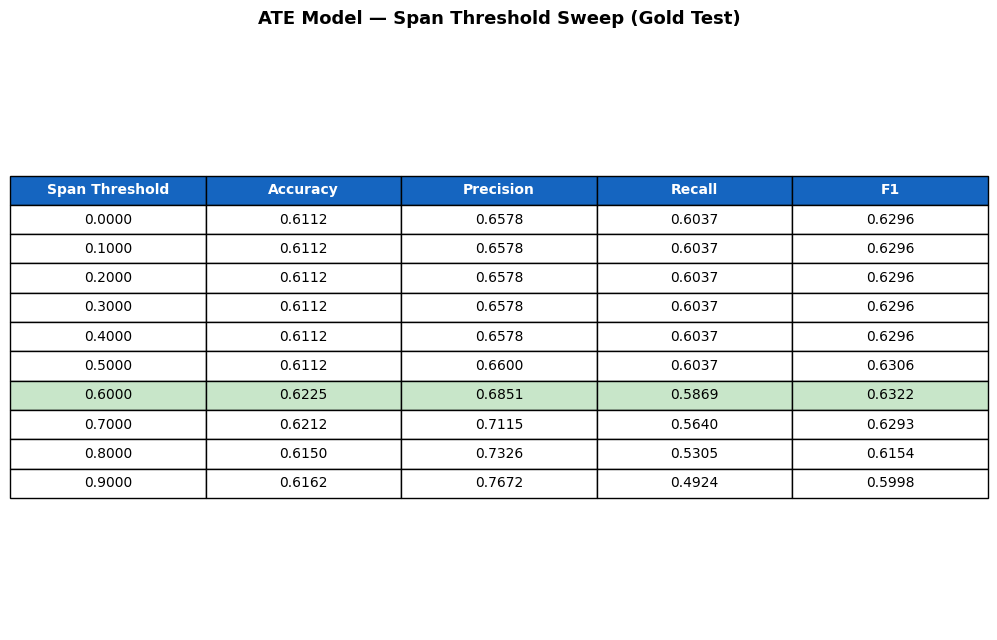

Saved: /content/drive/MyDrive/output_cleaning/absa_self_train_phase2/reports/ate_line_plot.png


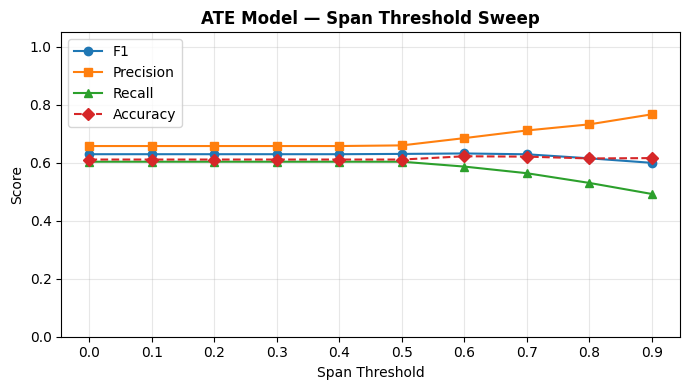

In [15]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"font.size": 10})

def make_table_figure(df, title, col_labels, save_path):
    cell_text = [[f"{v:.4f}" if isinstance(v, float) else str(v) for v in row] for _, row in df.iterrows()]
    fig, ax   = plt.subplots(figsize=(10, len(df) * 0.5 + 1.5))
    ax.axis("off")
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
    best_row = int(df["f1"].idxmax())
    for c in range(len(col_labels)): tbl[best_row + 1, c].set_facecolor("#c8e6c9")
    for c in range(len(col_labels)): tbl[0, c].set_facecolor("#1565c0"); tbl[0, c].set_text_props(color="white", fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    fig.tight_layout(); fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}"); plt.show()

make_table_figure(
    ate_result_df,
    title="ATE Model — Span Threshold Sweep (Gold Test)",
    col_labels=["Span Threshold", "Accuracy", "Precision", "Recall", "F1"],
    save_path=f"{REPORT_DIR}/ate_threshold_table.png",
)

fig, ax = plt.subplots(figsize=(7, 4))
x = ate_result_df["span_threshold"]
ax.plot(x, ate_result_df["f1"],        label="F1",       marker="o")
ax.plot(x, ate_result_df["precision"],  label="Precision", marker="s")
ax.plot(x, ate_result_df["recall"],     label="Recall",    marker="^")
ax.plot(x, ate_result_df["accuracy"],   label="Accuracy",  marker="D", linestyle="--")
ax.set_xlabel("Span Threshold"); ax.set_ylabel("Score")
ax.set_title("ATE Model — Span Threshold Sweep", fontweight="bold")
ax.set_xticks(x); ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
ate_line_path = f"{REPORT_DIR}/ate_line_plot.png"
fig.savefig(ate_line_path, dpi=150, bbox_inches="tight")
print(f"Saved: {ate_line_path}"); plt.show()